# Fit a 2-D Exponential to a 2-D histogram of star counts from Match Filter
## Charlotte Christensen, June 18, 2026

In [1]:
import numpy as np
from astropy.io import fits
from scipy.optimize import curve_fit

In [2]:
hdul = fits.open('/home/otteleno/MAP/matched_filter_plots/storm_2_data.fits')

In [3]:
data=hdul[0].data

In [4]:
hdul.info()

Filename: /home/otteleno/MAP/matched_filter_plots/storm_2_data.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   (89, 89)   float64   


In [5]:
# 1. Define the 2-D exponential model function
# The first argument must accept the combined X and Y coordinate array
def exponential_2d(coords, A, h, q, x_offset, y_offset, theta, C):
    # Parameters: A is amplitude, h is scale length, q is axis ratio (ie., minor/major; related to orientation), 
    # theta is rotation angle in viewing plane, C is offset from background (should be about zero)
    # theta = 0 means major axis is along x-axis, theta = pi/2 means major axis is along y-axis
    x = coords[0] - x_offset
    y = coords[1] - y_offset
    x_prime = x * np.cos(theta) + y * np.sin(theta)
    y_prime = -x * np.sin(theta) + y * np.cos(theta)
    r = np.sqrt(x_prime**2 + y_prime**2/q**2)
    return A * np.exp(-r/h) + C

In [6]:
# 2. Generate synthetic mock data with noise
x_line = np.linspace(-60, 60, 89)
y_line = np.linspace(-60, 60, 89)
X, Y = np.meshgrid(x_line, y_line)

# 3. Flatten the arrays to 1-D for curve_fit
x_flat = X.ravel()
y_flat = Y.ravel()
z_flat = data.ravel()

# Combine independent variables into an (2, N) shaped array
independent_vars = np.vstack((x_flat, y_flat))

In [7]:
# 4. Provide a sensible initial guess (p0) to prevent divergence
# Form: [A, h, q, x_offset, y_offset, theta, C]
initial_guess = [7, 2, 2, 10, 0, 0, 0]

# 5. Perform the optimization
fitted_params, covariance = curve_fit(
    f=exponential_2d, 
    xdata=independent_vars, 
    ydata=z_flat, 
    p0=initial_guess
)

In [8]:
# 6. Extract and view results
A_fit, h_fit, q_fit, x_offset_fit, y_offset_fit, theta_fit, C_fit= fitted_params
print("Fitted Parameters:")
print(f"A  = {A_fit:.4f}")
print(f"h = {h_fit:.4f}")
print(f"q = {q_fit:.4f}")
print(f"x_offset = {x_offset_fit:.4f}")
print(f"y_offset = {y_offset_fit:.4f}")
print(f"C  = {C_fit:.4f}")
print(f"theta = {theta_fit:.4f}")

Fitted Parameters:
A  = 596.1692
h = 2.0006
q = 1.9187
x_offset = 6.7210
y_offset = -0.6218
C  = 0.0289
theta = -0.1143


In [9]:
Z_fitted = exponential_2d((X, Y), *fitted_params)

[ 0.05961982  0.59619816  5.96198165 59.61981645]


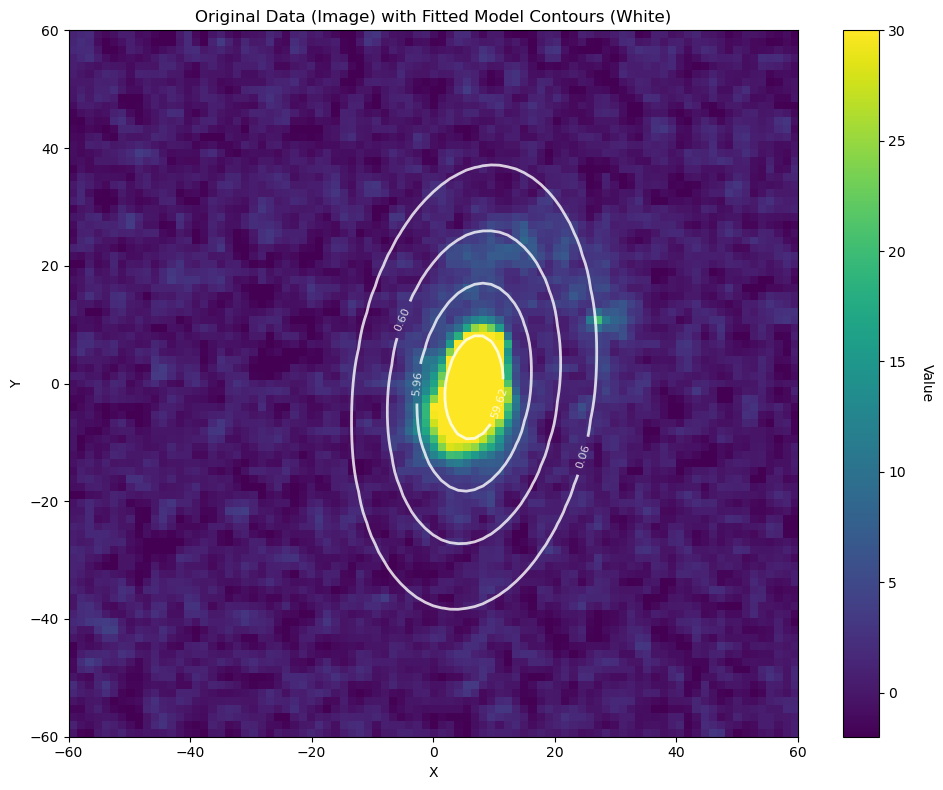

In [18]:
import matplotlib.pyplot as plt

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 8))

# Plot the original noisy data as an image
im = ax.imshow(data, origin='lower', extent=[x_line.min(), x_line.max(), y_line.min(), y_line.max()], 
               cmap='viridis', vmin=-2, vmax=30, aspect='auto')

# Overlay contours of the fitted result
levels_arr = 10.0**np.array([-4,-3,-2,-1])*(A_fit + C_fit)
print(levels_arr)
contours = ax.contour(X, Y, Z_fitted, colors='white', linewidths=2, levels=levels_arr, alpha=0.8)
ax.clabel(contours, inline=True, fontsize=8, fmt='%.2f')

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Value', rotation=270, labelpad=20)

# Labels and title
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Original Data (Image) with Fitted Model Contours (White)')

plt.tight_layout()
plt.show()




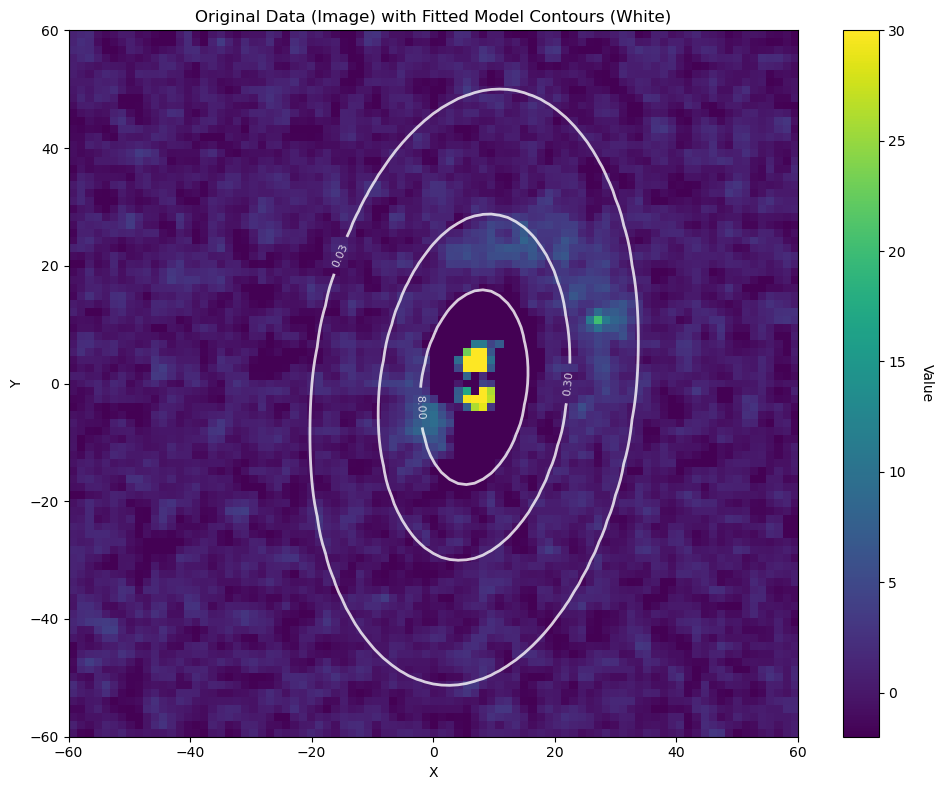

In [11]:
# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 8))

# Plot the original noisy data as an image
im = ax.imshow(data-Z_fitted, origin='lower', extent=[x_line.min(), x_line.max(), y_line.min(), y_line.max()], 
               cmap='viridis', vmin=-2, vmax=30, aspect='auto')

# Overlay contours of the fitted result
contours = ax.contour(X, Y, Z_fitted, colors='white', linewidths=2, levels=[0.03, 0.3, 8], alpha=0.8)
ax.clabel(contours, inline=True, fontsize=8, fmt='%.2f')

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Value', rotation=270, labelpad=20)

# Labels and title
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Original Data (Image) with Fitted Model Contours (White)')

plt.tight_layout()
plt.show()

In [12]:
np.shape(data-Z_fitted)

(89, 89)

In [13]:
my_save_path = f"/home/otteleno/MAP/matched_filter_plots/residuals/storm_2_test.fits"

hdu = fits.PrimaryHDU(data-Z_fitted)
hdu.header['SRC_ID'] = my_save_path
hdu.writeto(my_save_path, overwrite=True)

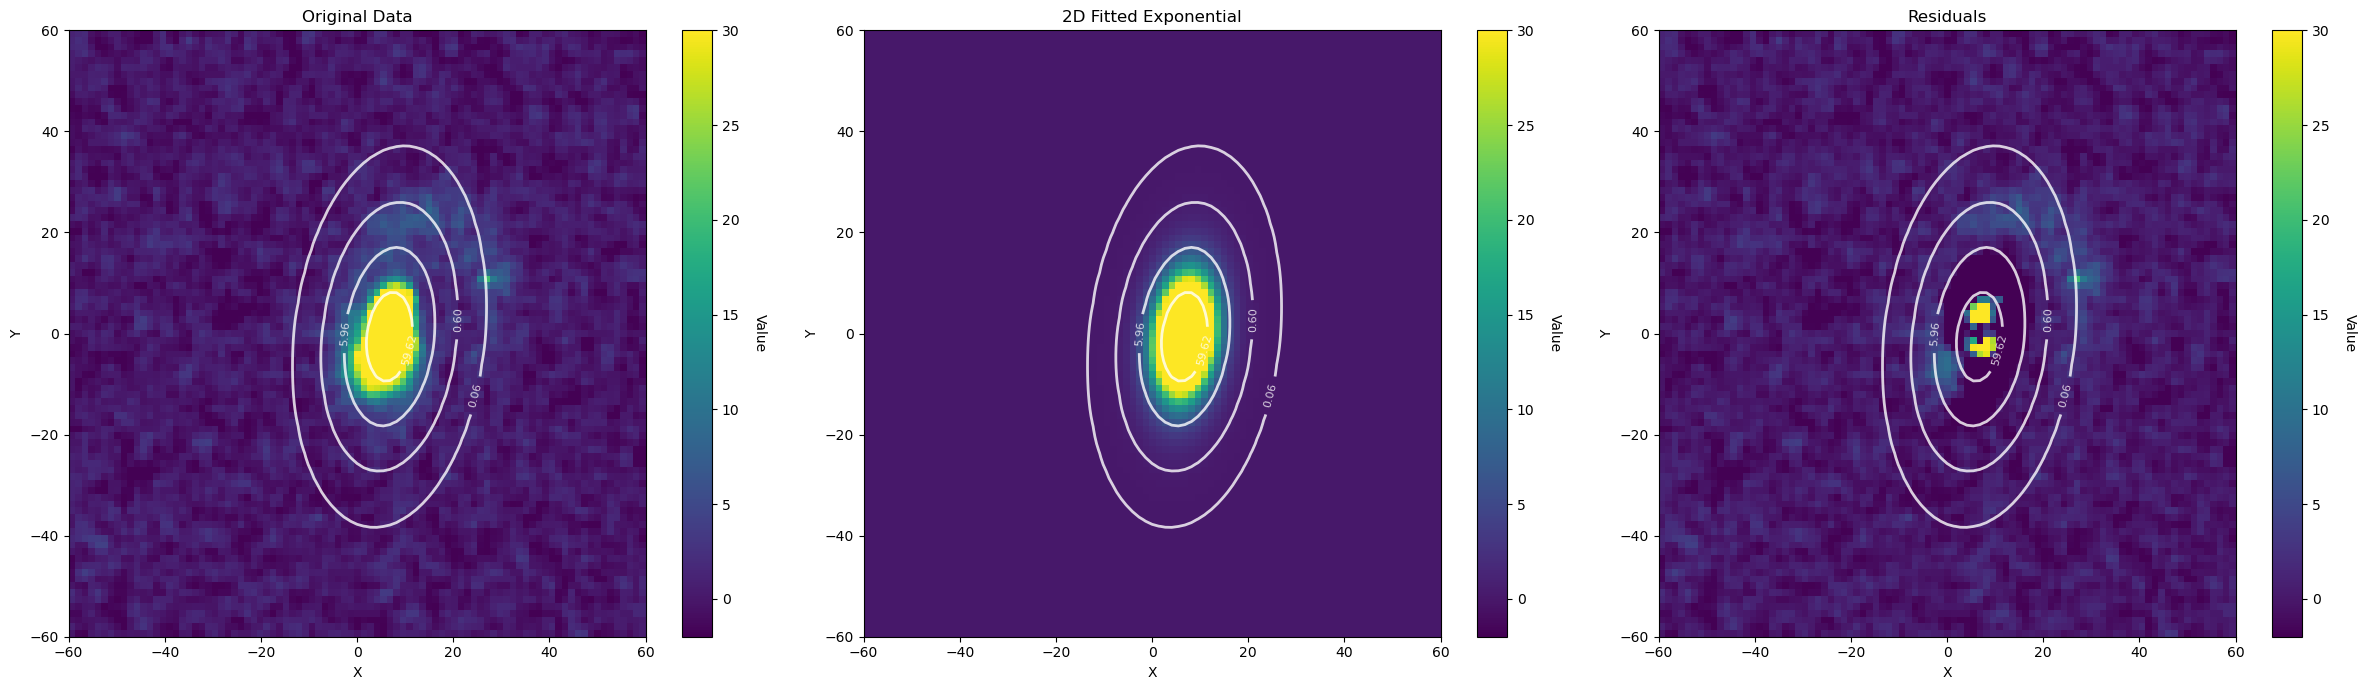

In [25]:
# Create a 1x3 figure and axis array
fig, axs = plt.subplots(1, 3, figsize=(24, 7))

# Plot 1: Original Data
im = axs[0].imshow(data, origin='lower', extent=[x_line.min(), x_line.max(), y_line.min(), y_line.max()], 
               cmap='viridis', vmin=-2, vmax=30, aspect='auto')
contours = axs[0].contour(X, Y, Z_fitted, colors='white', linewidths=2, levels=levels_arr, alpha=0.8)
axs[0].clabel(contours, inline=True, fontsize=8, fmt='%.2f')
cbar = plt.colorbar(im, ax=axs[0])
cbar.set_label('Value', rotation=270, labelpad=20)
axs[0].set_xlabel('X')
axs[0].set_ylabel('Y')
axs[0].set_title('Original Data')

# Plot 2: 2D Fitted Exponential
im = axs[1].imshow(Z_fitted, origin='lower', extent=[x_line.min(), x_line.max(), y_line.min(), y_line.max()], 
               cmap='viridis', vmin=-2, vmax=30, aspect='auto')
contours = axs[1].contour(X, Y, Z_fitted, colors='white', linewidths=2, levels=levels_arr, alpha=0.8)
axs[1].clabel(contours, inline=True, fontsize=8, fmt='%.2f')
cbar = plt.colorbar(im, ax=axs[1])
cbar.set_label('Value', rotation=270, labelpad=20)
axs[1].set_xlabel('X')
axs[1].set_ylabel('Y')
axs[1].set_title('2D Fitted Exponential')

# Plot 3: Residuals
im = axs[2].imshow(data - Z_fitted, origin='lower', extent=[x_line.min(), x_line.max(), y_line.min(), y_line.max()], 
               cmap='viridis', vmin=-2, vmax=30, aspect='auto')
contours = axs[2].contour(X, Y, Z_fitted, colors='white', linewidths=2, levels=levels_arr, alpha=0.8)
axs[2].clabel(contours, inline=True, fontsize=8, fmt='%.2f')
cbar = plt.colorbar(im, ax=axs[2])
cbar.set_label('Value', rotation=270, labelpad=20)
axs[2].set_xlabel('X')
axs[2].set_ylabel('Y')
axs[2].set_title('Residuals')

plt.tight_layout()
